    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Run task_1.py to generate representative vector database if not already generated.
    3. Press Run All (or restart kernel and run all cells).
    4. You will be prompted to provide input values.


    – Task 1: Implement a program which, given (a) a query label, l (b) a user selected feature space, and (c) 
    positive integer k, identifies and visualizes the most relevant k images for the given label l, along with 
    their scores, under the selected feature space.

In [7]:
LABEL = input("Provide a label present in the Caltech101 dataset.")

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc].")

K = int(input("Enter K, the number of similar images K to find for the selected feature space."))

In [8]:
# Find the k most similar images for a given query label for the given feature space.

print("Input label: ", LABEL)

Input label:  Faces


In [9]:
from utils.database_utils import retrieve
feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')
rep_feature_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

In [10]:
def filter_by_label(feature_vectors, label):
    filtered_fvs = {}
    for k, v in feature_vectors.items():
        if v[0] == label:
           filtered_fvs[k] = v 
    return filtered_fvs

Files already downloaded and verified

K = 5  most similar images by  color  feature space using distance:  cityblock
1. 	Image ID:  284 		Distance:  15927.23979710068


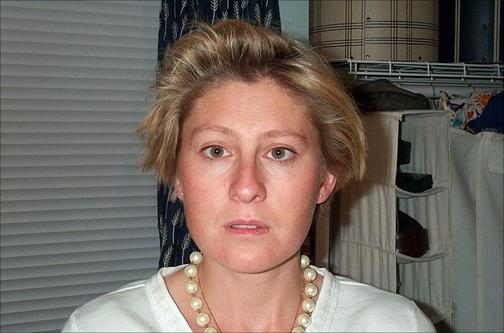

2. 	Image ID:  220 		Distance:  15961.139527386124


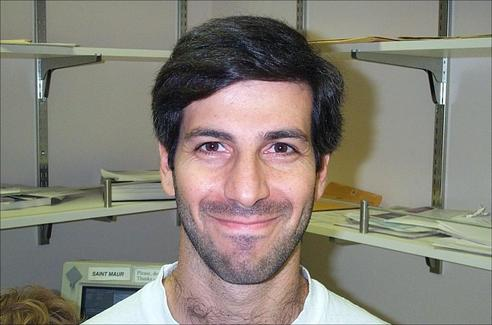

3. 	Image ID:  46 		Distance:  16010.785006107251


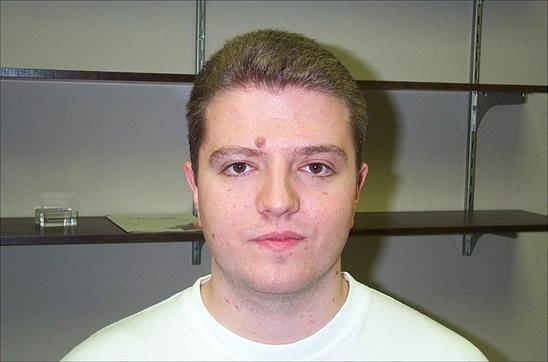

4. 	Image ID:  190 		Distance:  16097.618323305862


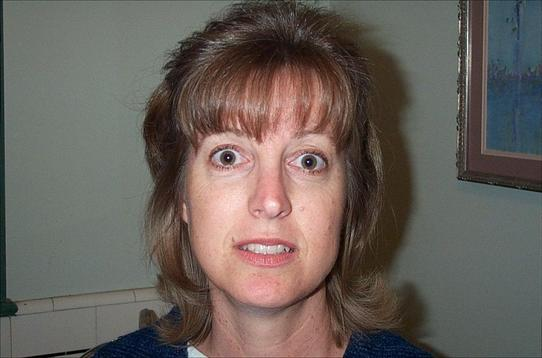

5. 	Image ID:  102 		Distance:  16141.832188751087


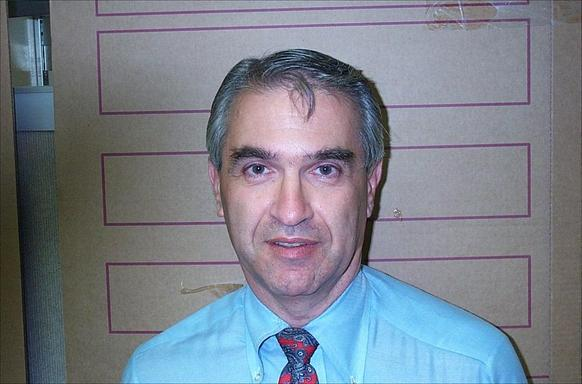

In [11]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()
label_space = dataset.categories

if LABEL not in label_space:
    print("ERROR - Provide correct label")
else:
    # rep_label_fv = rep_feature_vectors[LABEL]
    rep_label_fv = rep_feature_vectors[LABEL][0]
    filtered_fvs = filter_by_label(feature_vectors, LABEL)

    from utils.distance_utils import get_distance_fn, top_k_distance_ranker
    top_k = top_k_distance_ranker(K, rep_label_fv, filtered_fvs, get_distance_fn(FEATURE_SPACE))

    print("\nK =", K, " most similar images by ", FEATURE_SPACE, " feature space using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

    for i in range(len(top_k)):

        distance, image_id, label = top_k[i]

        print(str(i + 1) + ".", "\tImage ID: ", image_id, "\t\tDistance: ", distance)
        display(dataset[image_id][0])